In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
Accuracy_direct = {}

<center><strong>Working with CNN </strong></center>

In [3]:
# Directory containing the image dataset
train_data_dir = 'Rice Leaf Disease Images'

# Parameters for image preprocessing and augmentation
batch_size = 32
image_size = (224, 224)
num_classes = 4  # Update this based on your dataset

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pickle
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [9]:
# Directory containing the image dataset
train_data_dir = 'Rice Leaf Disease Images\Training'
test_data_dir = 'Rice Leaf Disease Images\Testing'

# Parameters for image preprocessing and augmentation
batch_size = 32
image_size = (100, 100)  # Adjust based on the input shape of your model
num_classes = 4  # Number of classes in the dataset

Found 5533 images belonging to 4 classes.
Found 400 images belonging to 4 classes.


c:\Users\yethi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10


c:\Users\yethi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


173/173 ━━━━━━━━━━━━━━━━━━━━ 64s 350ms/step - accuracy: 0.5279 - loss: 1.0567 - val_accuracy: 0.7475 - val_loss: 0.6587
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 57s 324ms/step - accuracy: 0.7498 - loss: 0.6240 - val_accuracy: 0.8500 - val_loss: 0.3997
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 56s 321ms/step - accuracy: 0.8381 - loss: 0.4068 - val_accuracy: 0.8450 - val_loss: 0.3784
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 55s 311ms/step - accuracy: 0.8807 - loss: 0.3037 - val_accuracy: 0.8850 - val_loss: 0.2753
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.9099 - loss: 0.2485 - val_accuracy: 0.9375 - val_loss: 0.1868
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 55s 311ms/step - accuracy: 0.9255 - loss: 0.2063 - val_accuracy: 0.9375 - val_loss: 0.1506
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.9277 - loss: 0.1992 - val_accuracy: 0.9525 - val_loss: 0.1018
Epoch 8/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.9334 - loss: 0.1776 - val

Model and class indices saved.
Final training accuracy: 0.9582505226135254
Final validation accuracy: 0.9624999761581421
Found 400 images belonging to 4 classes.
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


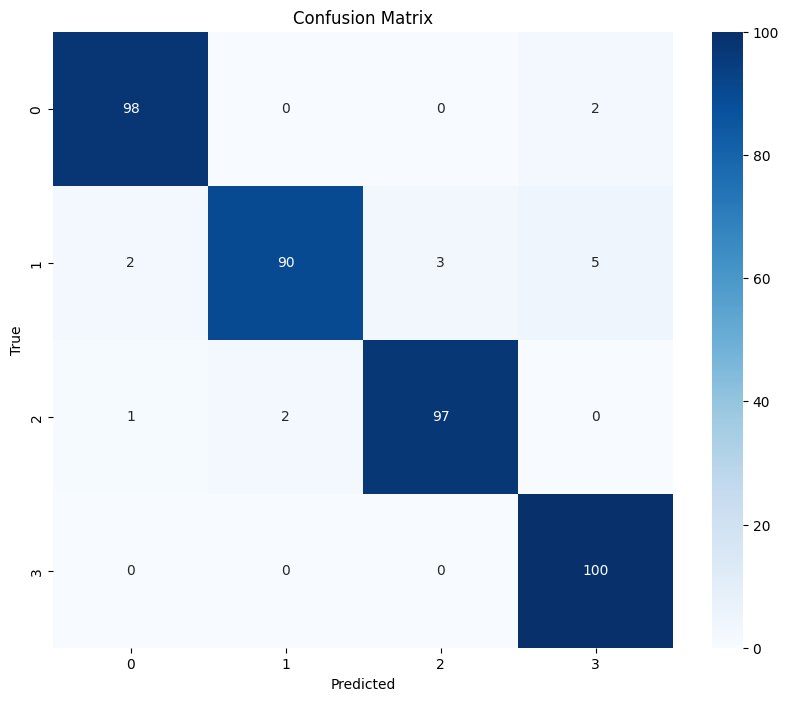

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.98      0.90      0.94       100
           2       0.97      0.97      0.97       100
           3       0.93      1.00      0.97       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [10]:
# Create an ImageDataGenerator for preprocessing and data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,             
    rotation_range=20,          
    width_shift_range=0.2,      
    height_shift_range=0.2,     
    shear_range=0.2,            
    zoom_range=0.2,             
    horizontal_flip=True,       
    fill_mode='nearest'         
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generate batches of augmented data from the directory
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=image_size,  
    batch_size=batch_size,
    class_mode='categorical'
)

# Generate batches of validation data from the testing directory
val_generator = val_test_datagen.flow_from_directory(
    test_data_dir,
    target_size=image_size,  
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important to keep the order for evaluation
)

# Define and compile the CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

# Save the trained model as an HDF5 file
model_filename = "CNN_trained_model.h5"
model.save(model_filename)

# Save the class indices dictionary to a pickle file
class_indices = train_generator.class_indices
pkl_filename = model_filename.split(".")[0] + "_class_indices.pkl"
with open(pkl_filename, "wb") as f:
    pickle.dump(class_indices, f)
    
print("Model and class indices saved.")

# Print final training and validation accuracy
print(f"Final training accuracy: {history.history['accuracy'][-1]}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]}")

# Evaluate the model on the test data
test_generator = val_test_datagen.flow_from_directory(
    test_data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions for the test dataset
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the true labels for the test dataset
y_true = test_generator.classes

<Strong><Center>integrate the confusion matrix into the code to analyze the model's performance. </Center></Strong>

Model and class indices saved.


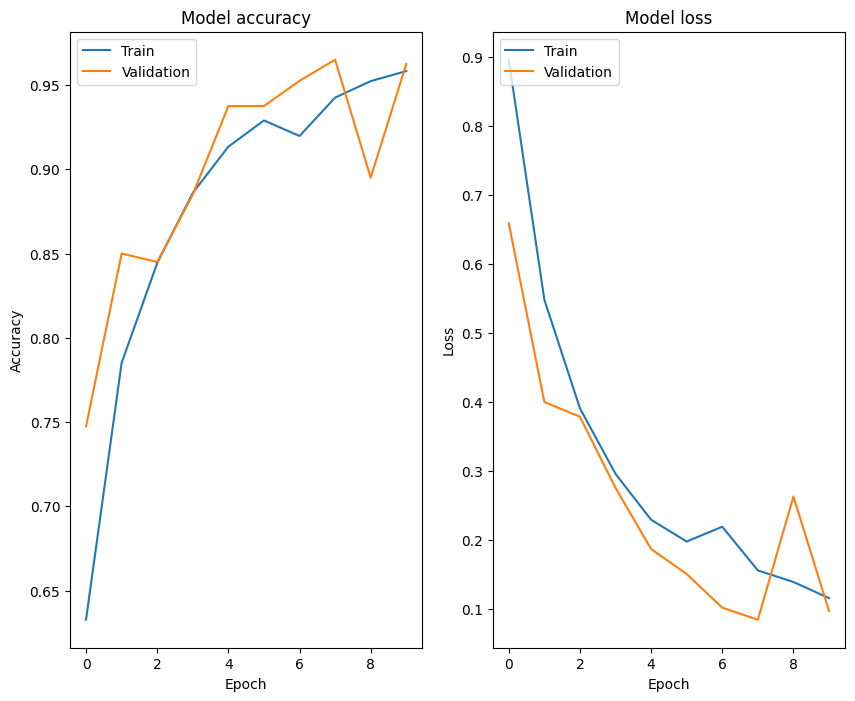

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9598 - loss: 0.1091
Testing Loss: 0.09700890630483627
Testing Accuracy: 0.9624999761581421
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step


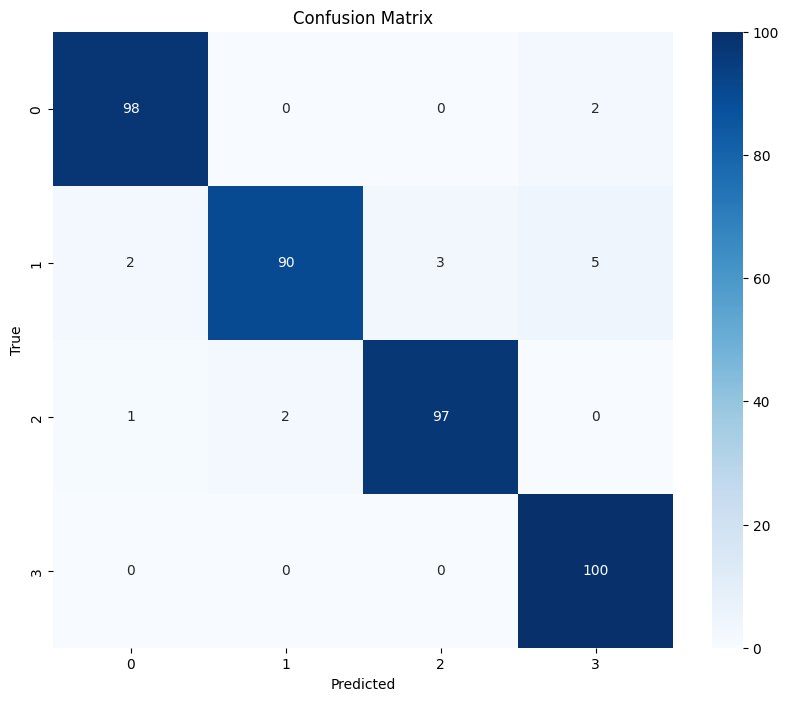

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.98      0.90      0.94       100
           2       0.97      0.97      0.97       100
           3       0.93      1.00      0.97       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [17]:
# Train the model
# Save the trained model as an HDF5 file
model_filename = "CNN_trained_model.h5"
model.save(model_filename)

# Save the class indices dictionary to a pickle file
class_indices = train_generator.class_indices
pkl_filename = model_filename.split(".")[0] + "_class_indices.pkl"
with open(pkl_filename, "wb") as f:
    pickle.dump(class_indices, f)

print("Model and class indices saved.")

# Plot the training and validation accuracy and loss
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# Evaluate the model on the testing data
loss, accuracy = model.evaluate(test_generator)
print("Testing Loss:", loss)
print("Testing Accuracy:", accuracy)

# Generate predictions for the test dataset
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the true labels for the test dataset
y_true = test_generator.classes

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate the classification report
print(classification_report(y_true, y_pred_classes))


Model and class indices saved.


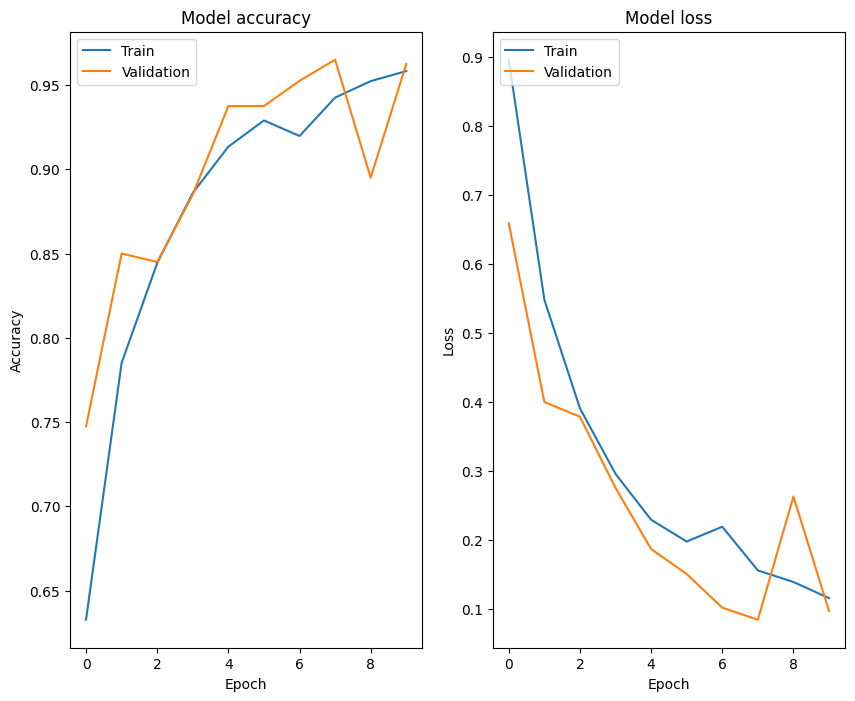

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9598 - loss: 0.1091
Testing Loss: 0.09700890630483627
Testing Accuracy: 0.9624999761581421
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step


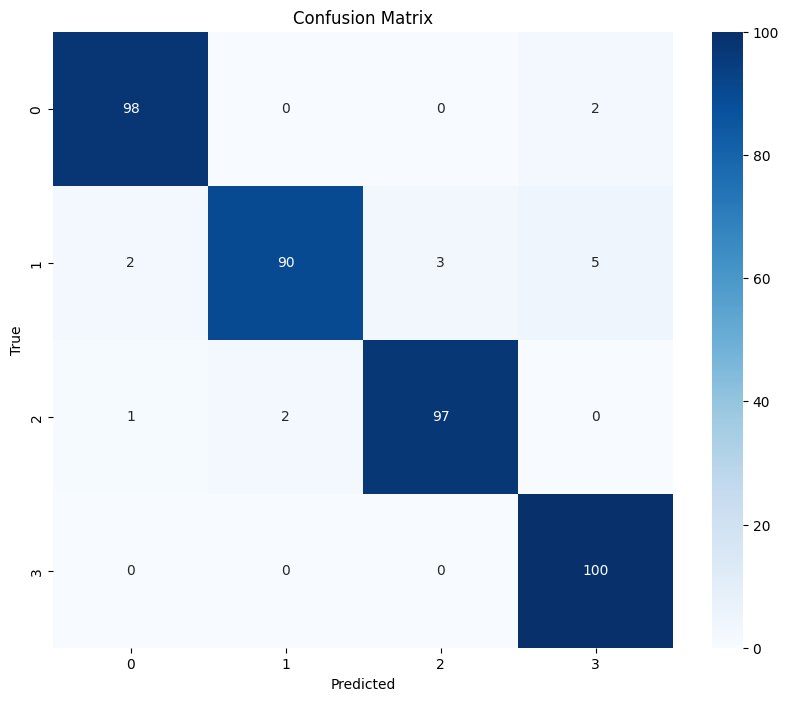

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.98      0.90      0.94       100
           2       0.97      0.97      0.97       100
           3       0.93      1.00      0.97       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [ ]:
# Train the model
# Save the trained model as an HDF5 file
model_filename = "CNN_trained_model.h5"
model.save(model_filename)

# Save the class indices dictionary to a pickle file
class_indices = train_generator.class_indices
pkl_filename = model_filename.split(".")[0] + "_class_indices.pkl"
with open(pkl_filename, "wb") as f:
    pickle.dump(class_indices, f)

print("Model and class indices saved.")

# Plot the training and validation accuracy and loss
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# Evaluate the model on the testing data
loss, accuracy = model.evaluate(test_generator)
print("Testing Loss:", loss)
print("Testing Accuracy:", accuracy)

# Generate predictions for the test dataset
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the true labels for the test dataset
y_true = test_generator.classes

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate the classification report
print(classification_report(y_true, y_pred_classes))


<center><strong>Working with Logistic Regression</strong></center>

In [59]:
import os
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgba2rgb, rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import joblib

In [61]:
# Function to load and preprocess images
def load_and_preprocess_data(data_dir, image_size, max_images=None):
    images = []
    labels = []
    image_count = 0
    
    # Iterate through each class subdirectory
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        
        # Load and preprocess images in the class subdirectory
        for image_file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_file)
            
            # Read the image
            image = imread(image_path)
            
            # Convert RGBA to RGB if necessary
            if image.shape[2] == 4:
                image = rgba2rgb(image)
            
            # Resize the image
            image = resize(image, image_size)
            
            # Convert the image to grayscale
            grayscale_image = rgb2gray(image)
            
            # Flatten the grayscale image and append to the list of images
            flattened_image = grayscale_image.flatten()
            images.append(flattened_image)
            
            # Append the label (class name) to the list of labels
            labels.append(class_name)
            
            image_count += 1
            if max_images and image_count >= max_images:
                break
        
        if max_images and image_count >= max_images:
            break
    
    # Convert lists to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

Training Accuracy: 1.0
Testing Accuracy: 0.9075


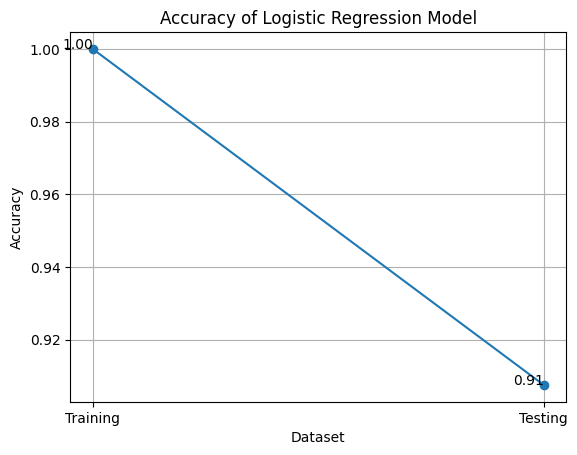

In [62]:
# Define the directory containing the image dataset
data_dir = 'Rice Leaf Disease Images/Training'

# Define the target size for resizing the images
image_size = (100, 100)  # Adjust as needed

# Limit the number of images to 2000
max_images = 2000

# Load and preprocess the data
images, labels = load_and_preprocess_data(data_dir, image_size, max_images)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Initialize and train logistic regression model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

# Evaluate the model
train_accuracy = logistic_model.score(X_train, y_train)
test_accuracy = logistic_model.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)


Accuracy_direct['Logistic Regression [Training,testing]'] = [train_accuracy,test_accuracy]

# Save the trained model
joblib.dump(logistic_model, 'logistic_regression_model.pkl')

# Plot the accuracy
plt.plot(['Training', 'Testing'], [train_accuracy, test_accuracy], marker='o', linestyle='-')
plt.title('Accuracy of Logistic Regression Model')
plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.grid(True)  # Add grid lines for better visualization

# Show the values on the plot
plt.text('Training', train_accuracy, f'{train_accuracy:.2f}', ha='right')
plt.text('Testing', test_accuracy, f'{test_accuracy:.2f}', ha='right')

plt.show()

<center><strong>Working With Random Forest</strong></center>

In [35]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import joblib
import h5py
from sklearn.preprocessing import LabelEncoder

In [36]:
# Function to load and preprocess images
def load_and_preprocess_data(data_dir, image_size, max_images=None):
    images = []
    labels = []
    image_count = 0
    
    # Iterate through each class subdirectory
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        
        # Load and preprocess images in the class subdirectory
        for image_file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_file)
            
            # Read the image
            image = imread(image_path)
            
            # Convert RGBA to RGB if necessary
            if image.shape[2] == 4:
                image = rgba2rgb(image)
            
            # Resize the image
            image = resize(image, image_size)
            
            # Convert the image to grayscale
            grayscale_image = rgb2gray(image)
            
            # Flatten the grayscale image and append to the list of images
            flattened_image = grayscale_image.flatten()
            images.append(flattened_image)
            
            # Append the label (class name) to the list of labels
            labels.append(class_name)
            
            image_count += 1
            if max_images and image_count >= max_images:
                break
        
        if max_images and image_count >= max_images:
            break
    
    # Convert lists to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.9125


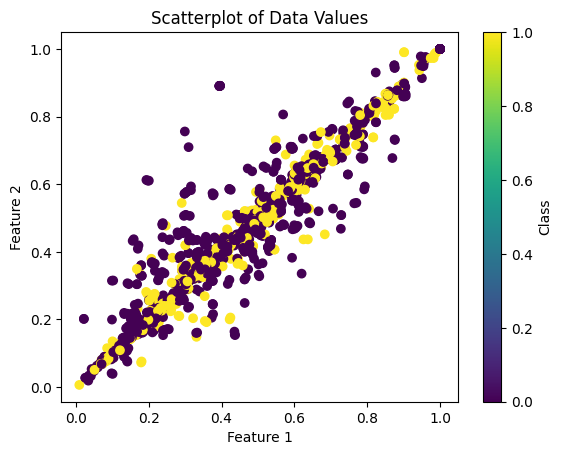

In [37]:
# Define the directory containing the image dataset
data_dir = 'Rice Leaf Disease Images\Training'

# Define the target size for resizing the images
image_size = (100, 100)  # Adjust as needed

# Limit the number of images to 2000
max_images = 2000

# Load and preprocess the data
images, labels = load_and_preprocess_data(data_dir, image_size, max_images)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Initialize and train Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Evaluate the model
train_accuracy_rf = random_forest_model.score(X_train, y_train)
test_accuracy_rf = random_forest_model.score(X_test, y_test)
print("Random Forest Training Accuracy:", train_accuracy_rf)
print("Random Forest Testing Accuracy:", test_accuracy_rf)

Accuracy_direct['Random Forest [Training,testing]'] = [train_accuracy_rf,test_accuracy_rf]

# Save the trained model as a joblib file
pkl_model_filename = "random_forest_model.pkl"
joblib.dump(random_forest_model, pkl_model_filename)

# Encode class labels to numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Plot a scatterplot for the data values
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train_encoded, cmap='viridis')
plt.colorbar(label='Class')
plt.title('Scatterplot of Data Values')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<strong><center>Working With K-Mean</center></strong>

In [39]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize
import os
from skimage.color import rgba2rgb

In [41]:
# Function to load and preprocess images
def load_and_preprocess_data(data_dir, image_size, max_images=None):
    images = []
    labels = []
    image_count = 0
    
    # Iterate through each class subdirectory
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        
        # Load and preprocess images in the class subdirectory
        for image_file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_file)
            
            # Read the image
            image = io.imread(image_path)
            
            # Convert RGBA to RGB if necessary
            if image.shape[-1] == 4:
                image = rgba2rgb(image)
            
            # Resize the image
            image = resize(image, image_size)
            
            # Convert the image to grayscale if it's not already
            if len(image.shape) == 3 and image.shape[-1] == 3:
                image = rgb2gray(image)
            
            # Flatten the image and append to the list of images
            flattened_image = image.flatten()
            images.append(flattened_image)
            
            # Append the label (class name) to the list of labels
            labels.append(class_name)
            
            image_count += 1
            if max_images and image_count >= max_images:
                break
        
        if max_images and image_count >= max_images:
            break
    
    # Convert lists to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

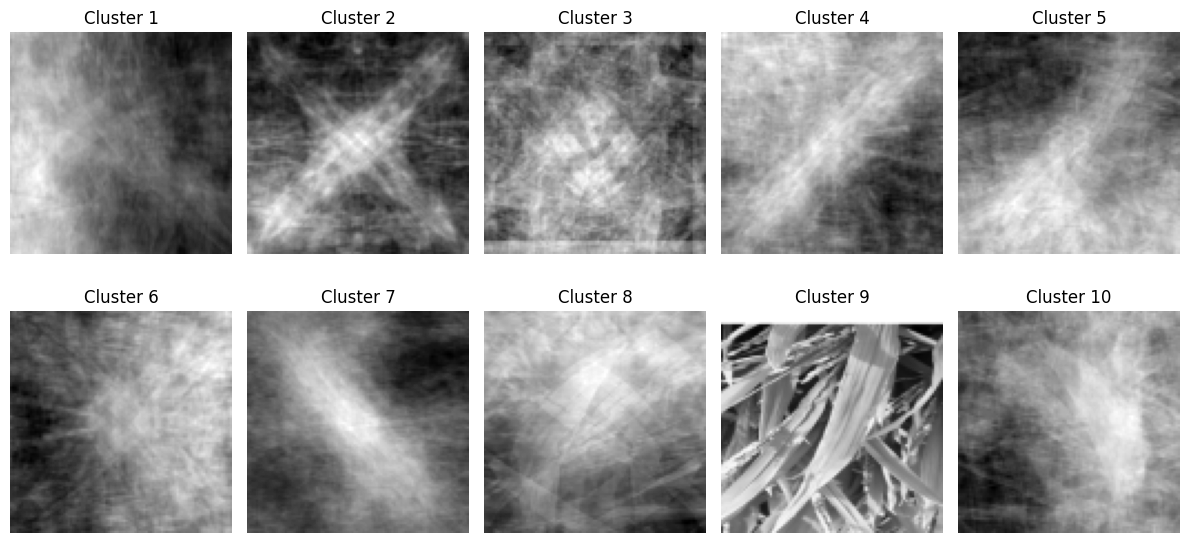

In [42]:
# Define the directory containing the image dataset
data_dir = 'Rice Leaf Disease Images/Training'

# Define the target size for resizing the images
image_size = (100, 100)  # Adjust as needed

# Limit the number of images to 2000
max_images = 2000

# Load and preprocess the data
images, labels = load_and_preprocess_data(data_dir, image_size, max_images)

# Reshape the images array to 2D
num_images, image_size_flat = images.shape[0], np.prod(image_size)
images_2d = images.reshape(num_images, image_size_flat)

# Apply K-Means
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(images_2d)

# Analyze clusters
cluster_centers = kmeans.cluster_centers_
labels = kmeans.labels_

# Visualize representative images from each cluster
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    representative_image = cluster_centers[i].reshape(image_size)
    ax.imshow(representative_image, cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout()
plt.show()


<Strong><Center>Working On K-Fold And Logistic Regression</Center></Strong>

In [66]:
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgba2rgb, rgb2gray

def load_and_preprocess_image(image_path, target_size):
    # Read the image
    image = imread(image_path)
    
    # Convert RGBA to RGB if necessary
    if image.shape[-1] == 4:
        image = rgba2rgb(image)
    
    # Resize the image
    image = resize(image, target_size)
    
    # Convert the image to grayscale if it's not already
    if len(image.shape) == 3 and image.shape[-1] == 3:
        image = rgb2gray(image)
    
    return image


In [67]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import os

# Define constants
NUM_FOLDS = 5
IMAGE_SIZE = (224, 224)  # Adjust as needed
DATA_DIR = 'Rice Leaf Disease Images\Training'
NUM_CLASSES = len(os.listdir(DATA_DIR))  # Assuming each subdirectory represents a class

# Load images and labels
images = []
labels = []

for class_idx, class_name in enumerate(os.listdir(DATA_DIR)):
    class_dir = os.path.join(DATA_DIR, class_name)
    for image_file in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_file)
        # Load and preprocess image
        image = load_and_preprocess_image(image_path, IMAGE_SIZE)  # Implement this function according to your preprocessing needs
        images.append(image)
        labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)

# Initialize K-Fold cross-validator
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

# Initialize logistic regression model
logistic_model = LogisticRegression(max_iter=1000)  # Adjust max_iter as needed

# Initialize list to store accuracy scores
accuracy_scores = []

# Iterate over each fold
for fold_idx, (train_indices, val_indices) in enumerate(kf.split(images)):
    print(f"Fold {fold_idx + 1}/{NUM_FOLDS}")
    
    # Split data into training and validation sets
    X_train, X_val = images[train_indices], images[val_indices]
    y_train, y_val = labels[train_indices], labels[val_indices]
    
    # Flatten the images
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_val_flat = X_val.reshape(X_val.shape[0], -1)
    
    # Train logistic regression model
    logistic_model.fit(X_train_flat, y_train)
    
    # Predict labels for validation set
    val_predictions = logistic_model.predict(X_val_flat)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_val, val_predictions)
    print(f"Validation Accuracy: {accuracy}")
    
    # Store accuracy score
    accuracy_scores.append(accuracy)

# Calculate mean and standard deviation of accuracy scores
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
print(f"Mean Accuracy: {mean_accuracy}")
print(f"Standard Deviation of Accuracy: {std_accuracy}")



# Validation Accuracy: 0.8987341772151899
# Mean Accuracy: 0.9078208539770751
# Standard Deviation of Accuracy: 0.015825006641597254

Fold 1/5
Validation Accuracy: 0.8970189701897019
Fold 2/5


c:\Users\yethi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.9259259259259259
Fold 3/5


c:\Users\yethi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.9277326106594399
Fold 4/5
Validation Accuracy: 0.8896925858951176
Fold 5/5


c:\Users\yethi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8987341772151899
Mean Accuracy: 0.9078208539770751
Standard Deviation of Accuracy: 0.015825006641597254


<Strong><Center>RandomForestClassifier model</Center></Strong>

In [46]:
import os
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [47]:
# Function to load and preprocess images
def load_and_preprocess_data(data_dir, image_size, max_images=None):
    images = []
    labels = []
    image_count = 0
    
    # Iterate through each class subdirectory
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        
        # Load and preprocess images in the class subdirectory
        for image_file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_file)
            
            # Read the image
            image = io.imread(image_path)
            
            # Convert RGBA to RGB if necessary
            if image.shape[-1] == 4:
                image = rgba2rgb(image)
            
            # Resize the image
            image = resize(image, image_size)
            
            # Convert the image to grayscale if it's not already
            if len(image.shape) == 3 and image.shape[-1] == 3:
                image = rgb2gray(image)
            
            # Flatten the image and append to the list of images
            flattened_image = image.flatten()
            images.append(flattened_image)
            
            # Append the label (class name) to the list of labels
            labels.append(class_name)
            
            image_count += 1
            if max_images and image_count >= max_images:
                break
        
        if max_images and image_count >= max_images:
            break
    
    # Convert lists to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

In [48]:
# Define the directory containing the image dataset
data_dir = 'Rice Leaf Disease Images\Training'

# Define the target size for resizing the images
image_size = (100, 100)  # Adjust as needed

# Load and preprocess the data
images, labels = load_and_preprocess_data(data_dir, image_size)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the RandomForestClassifier
rf_classifier.fit(X_train, y_train)

# Predict the labels for the test set
y_pred = rf_classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy_direct['RandomForestClassifier model '] = accuracy


Accuracy: 0.955736224028907


<Strong><center>Decision Tree classifier</center></Strong>

In [49]:
import os
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [52]:
# Function to load and preprocess images
def load_and_preprocess_data(data_dir, image_size, max_images=None):
    images = []
    labels = []
    image_count = 0
    
    # Iterate through each class subdirectory
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        
        # Load and preprocess images in the class subdirectory
        for image_file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_file)
            
            # Read the image
            image = io.imread(image_path)
            
            # Convert RGBA to RGB if necessary
            if image.shape[-1] == 4:
                image = rgba2rgb(image)
            
            # Resize the image
            image = resize(image, image_size)
            
            # Convert the image to grayscale if it's not already
            if len(image.shape) == 3 and image.shape[-1] == 3:
                image = rgb2gray(image)
            
            # Flatten the image and append to the list of images
            flattened_image = image.flatten()
            images.append(flattened_image)
            
            # Append the label (class name) to the list of labels
            labels.append(class_name)
            
            image_count += 1
            if max_images and image_count >= max_images:
                break
        
        if max_images and image_count >= max_images:
            break
    
    # Convert lists to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels


In [63]:
# Define the directory containing the image dataset
data_dir = 'Rice Leaf Disease Images\Training'

# Define the target size for resizing the images
image_size = (100, 100)  # Adjust as needed

# Load and preprocess the data
images, labels = load_and_preprocess_data(data_dir, image_size)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Initialize the DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the DecisionTreeClassifier
dt_classifier.fit(X_train, y_train)

# Predict the labels for the test set
y_pred = dt_classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy_direct['DecisionTree Classifier'] = [accuracy]

Accuracy: 0.8654019873532068


<Strong><Center>Support Vector Classifier (SVC) model </Center></Strong>

In [54]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import os
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgba2rgb, rgb2gray

In [55]:
# Define constants
IMAGE_SIZE = (100, 100)  # Adjust as needed
DATA_DIR = 'Rice Leaf Disease Images/Training'
NUM_CLASSES = len(os.listdir(DATA_DIR))  # Assuming each subdirectory represents a class

# Load images and labels
images = []
labels = []

for class_idx, class_name in enumerate(os.listdir(DATA_DIR)):
    class_dir = os.path.join(DATA_DIR, class_name)
    for image_file in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_file)
        # Load and preprocess image
        image = imread(image_path)
        image = resize(image, IMAGE_SIZE)
        if image.shape[-1] == 4:
            image = rgba2rgb(image)
        image_gray = rgb2gray(image)
        images.append(image_gray.flatten())
        labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Initialize SVC model
svc_model = SVC()

# Train the model
svc_model.fit(X_train, y_train)

# Make predictions
y_pred = svc_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy_direct['Support Vector Classifier (SVC) model '] = accuracy


Accuracy: 0.912375790424571


In [64]:
for key, value in Accuracy_direct.items():
    print(f"{key}: {value}")

CNN_trained_model: 0.9634917974472046
Random Forest [Training,testing]: [1.0, 0.9125]
RandomForestClassifier model : 0.955736224028907
Support Vector Classifier (SVC) model : 0.912375790424571
Logistic Regression [Training,testing]: [1.0, 0.9075]
DecisionTree Classifier: [0.8654019873532068]


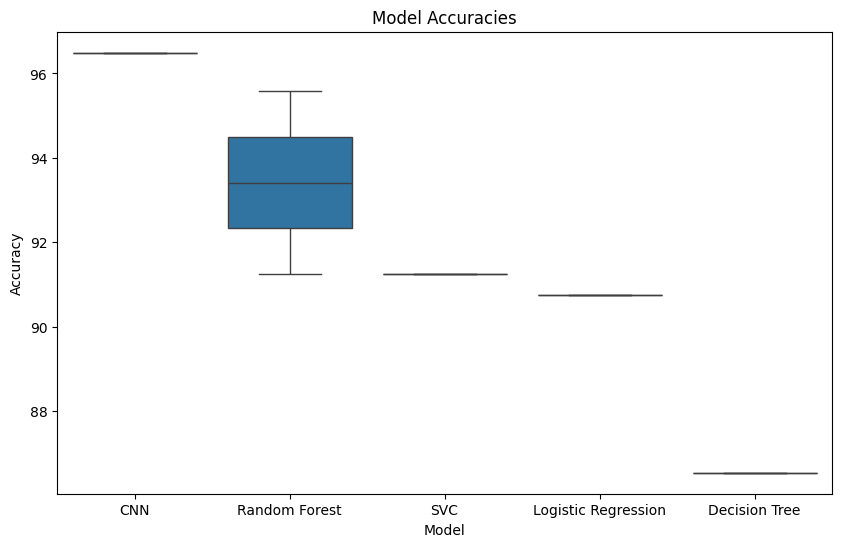

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from the provided model accuracies
data = {
    "CNN": [96.4917974472046],
    "Random Forest": [91.25, 95.5736224028907],  # Testing and separate result
    "SVC": [91.2375790424571],
    "Logistic Regression": [90.75],
    "Decision Tree": [86.54019873532068]
}

# Convert the data into a format suitable for Seaborn
model_names = []
accuracies = []

for model, acc_list in data.items():
    model_names.extend([model] * len(acc_list))
    accuracies.extend(acc_list)

# Create a DataFrame for better handling with Seaborn
import pandas as pd
df = pd.DataFrame({"Model": model_names, "Accuracy": accuracies})

# Plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Accuracy', data=df)

# Add title and labels
plt.title('Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')

# Display the plot
plt.show()


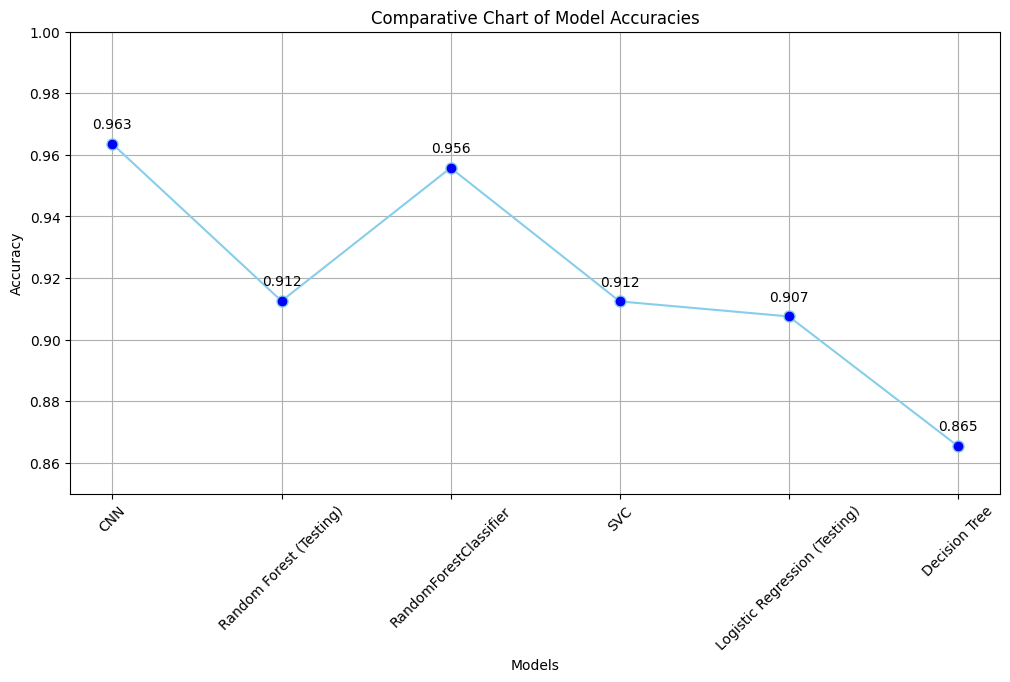

In [5]:
import matplotlib.pyplot as plt

# Data from the provided model accuracies
model_names = [
    "CNN", 
    "Random Forest (Testing)", 
    "RandomForestClassifier", 
    "SVC", 
    "Logistic Regression (Testing)", 
    "Decision Tree"
]

accuracies = [
    0.9634917974472046,
    0.9125,
    0.955736224028907,
    0.912375790424571,
    0.9075,
    0.8654019873532068
]

# Plotting the line graph
plt.figure(figsize=(12, 6))
plt.plot(model_names, accuracies, marker='o', linestyle='-', color='skyblue', markerfacecolor='blue', markersize=8)

# Adding title and labels
plt.title('Comparative Chart of Model Accuracies')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)  # Set the y-axis range for better visualization

# Adding grid for better readability
plt.grid(True)

# Adding the accuracy values on the points
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.005, f"{value:.3f}", ha='center')

# Display the plot
plt.xticks(rotation=45)  # Rotate the model names for better readability
plt.show()
